# ⚽ FIFA Players — Complete ML Assignment
## Tasks 1–8 (original) + Tasks 9–11 (RF · SVM · KNN · Ensembling · Pipeline & Validation)

| | Details |
|---|---|
| **Dataset** | FIFA Players — 19,667 records |
| **Regression target** | `Value Per M$` (log-transformed) |
| **Classification target** | `Performance_Tier` (Low / Mid / High / Elite) |
| **New models** | Random Forest, SVM, KNN |
| **Ensembling** | Voting (soft) + Stacking |
| **Validation** | 5-Fold CV with mean ± std |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing & pipeline ───────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score,
    learning_curve, KFold, StratifiedKFold
)

# ── Regression models ──────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# ── Classification models ──────────────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ── Ensembling ─────────────────────────────────────────────────────────────────
from sklearn.ensemble import (
    VotingRegressor, VotingClassifier,
    StackingRegressor, StackingClassifier
)

# ── Metrics ────────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
SEED = 42
TIER_ORDER  = ['Low', 'Mid', 'High', 'Elite']
TIER_COLORS = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
print('✅  All libraries loaded.')

✅  All libraries loaded.


---
## TASK 1 — Exploratory Data Analysis (EDA)

In [2]:
df = pd.read_csv('Fifa.csv')
print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
df.head()

Shape: (19667, 9)

Missing values:
Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


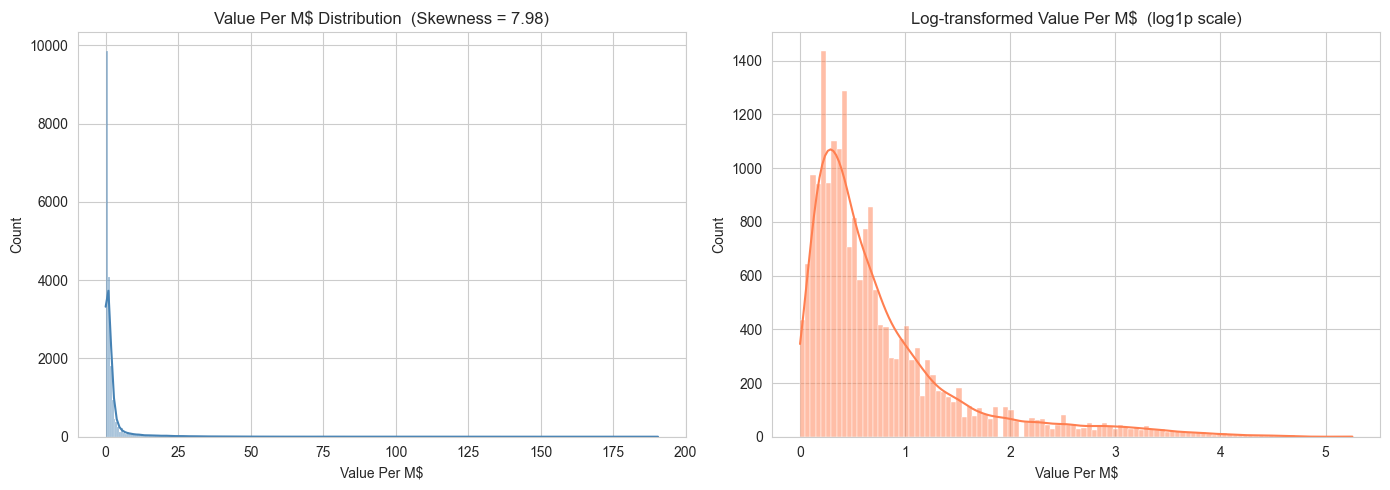

In [3]:
# Value distribution — original vs log-transformed
skewness = df['Value Per M$'].skew()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Value Per M$'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Value Per M$ Distribution  (Skewness = {skewness:.2f})')
sns.histplot(np.log1p(df['Value Per M$']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log-transformed Value Per M$  (log1p scale)')
plt.tight_layout(); plt.show()

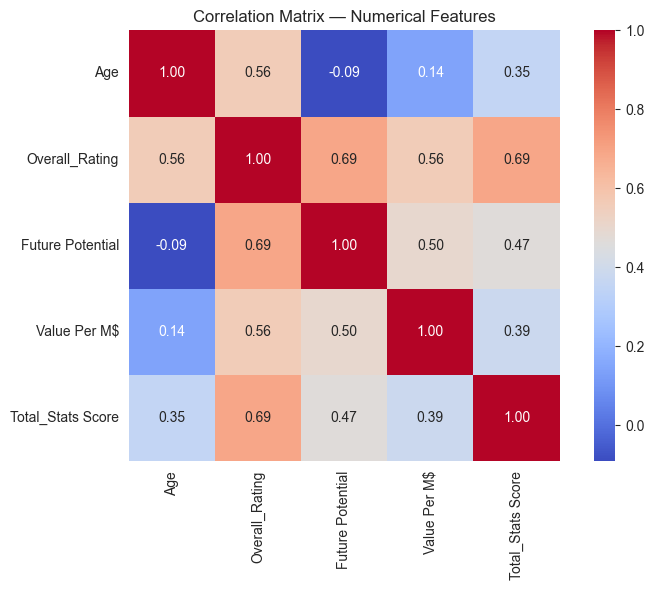


Correlation with Value Per M$:
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [4]:
# Correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout(); plt.show()
print('\nCorrelation with Value Per M$:')
print(corr['Value Per M$'].sort_values(ascending=False))

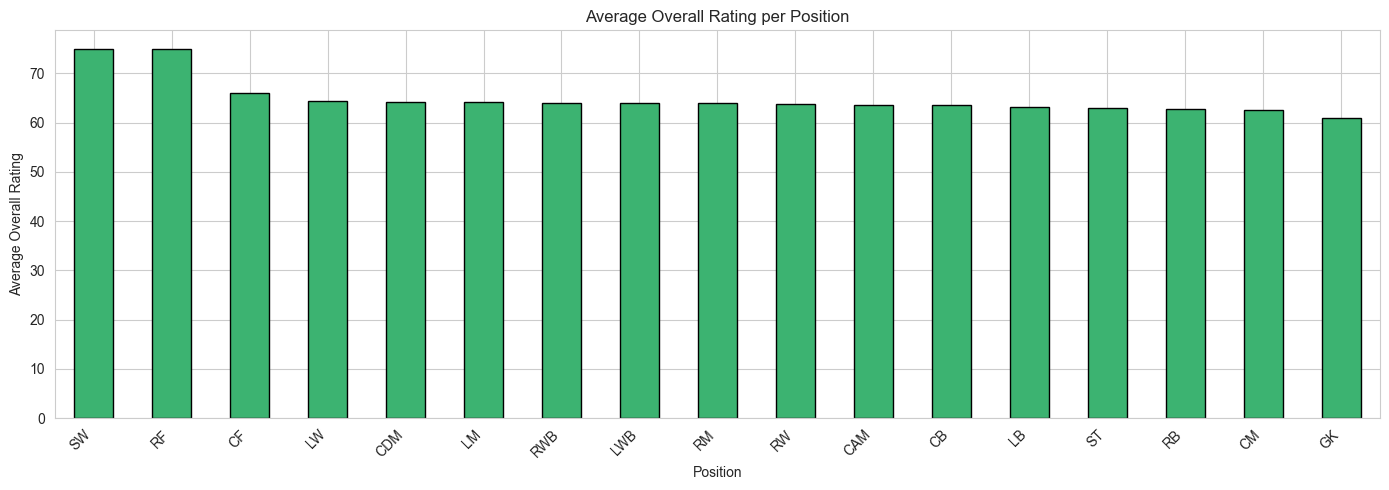

In [5]:
# Average Overall_Rating per Position
avg_rating = df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(14, 5))
avg_rating.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Average Overall Rating per Position')
plt.xlabel('Position'); plt.ylabel('Average Overall Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

---
## TASK 2 — Data Preprocessing

Train after outlier removal: 12920 rows


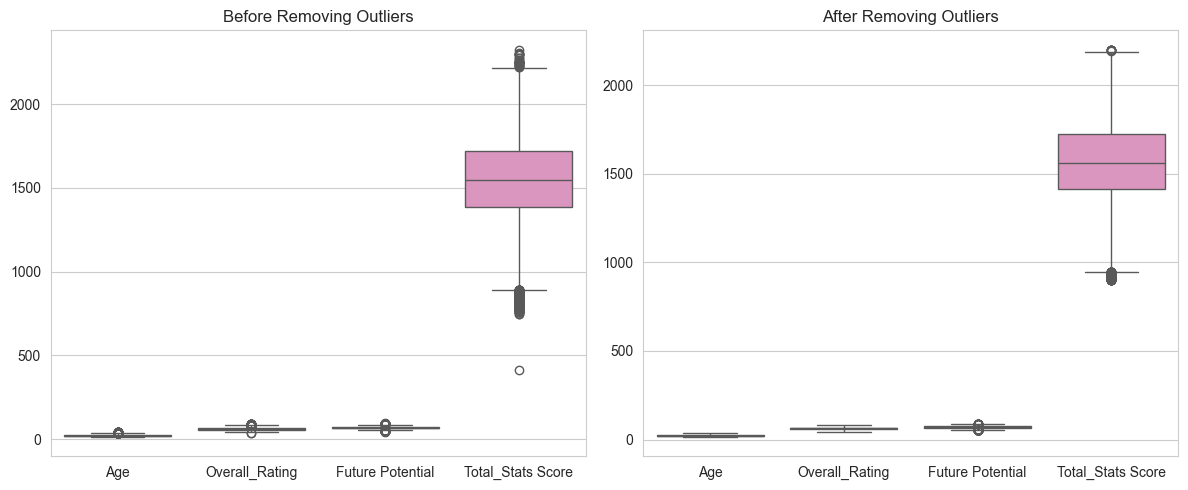

In [6]:
# ── Outlier removal helper ─────────────────────────────────────────────────────
def remove_outliers_iqr(df_in, cols):
    df_clean = df_in.copy()
    for col in cols:
        Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[
            (df_clean[col] >= Q1 - 1.5 * IQR) &
            (df_clean[col] <= Q3 + 1.5 * IQR)
        ]
    return df_clean

# Split before outlier removal to avoid data leakage
X_raw = df.drop('Value Per M$', axis=1)
y_raw = df['Value Per M$']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED
)

# Remove outliers on TRAIN only
num_cols_all = X_raw.select_dtypes(include=np.number).columns.tolist()
cat_cols_all = X_raw.select_dtypes(include='object').columns.tolist()

train_data = pd.concat([X_train_raw, y_train_raw], axis=1)
train_clean = remove_outliers_iqr(train_data, num_cols_all + ['Value Per M$'])

X_train_raw = train_clean.drop('Value Per M$', axis=1)
y_train_raw  = train_clean['Value Per M$']
print(f'Train after outlier removal: {X_train_raw.shape[0]} rows')

# Boxplot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df[num_cols_all], ax=axes[0], palette='Set2')
axes[0].set_title('Before Removing Outliers')
df_clean_viz = remove_outliers_iqr(df, num_cols_all)
sns.boxplot(data=df_clean_viz[num_cols_all], ax=axes[1], palette='Set2')
axes[1].set_title('After Removing Outliers')
plt.tight_layout(); plt.show()

In [7]:
# ── Full preprocessor pipeline (for Tasks 4–7 baseline models) ────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                       num_cols_all),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_all)
], remainder='drop')

full_pipeline = Pipeline(steps=[('preprocessing', preprocessor)])
X_train_processed = full_pipeline.fit_transform(X_train_raw)
X_test_processed  = full_pipeline.transform(X_test_raw)

y_train_raw = y_train_raw.reset_index(drop=True)
y_test_raw  = y_test_raw.reset_index(drop=True)

# Numerical only (for polynomial regression baseline)
scaler_num = StandardScaler()
X_train_num = scaler_num.fit_transform(X_train_raw[num_cols_all])
X_test_num  = scaler_num.transform(X_test_raw[num_cols_all])

ohe_names = (full_pipeline.named_steps['preprocessing']
             .named_transformers_['cat']
             .get_feature_names_out(cat_cols_all).tolist())
all_feature_names = num_cols_all + ohe_names
print(f'Total features after preprocessing: {len(all_feature_names)}')

Total features after preprocessing: 14040


---
## TASK 3 — Classification Target: Performance Tier

Threshold justification — Overall_Rating percentiles:
count    19667.000000
mean        63.225403
std          7.812716
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64


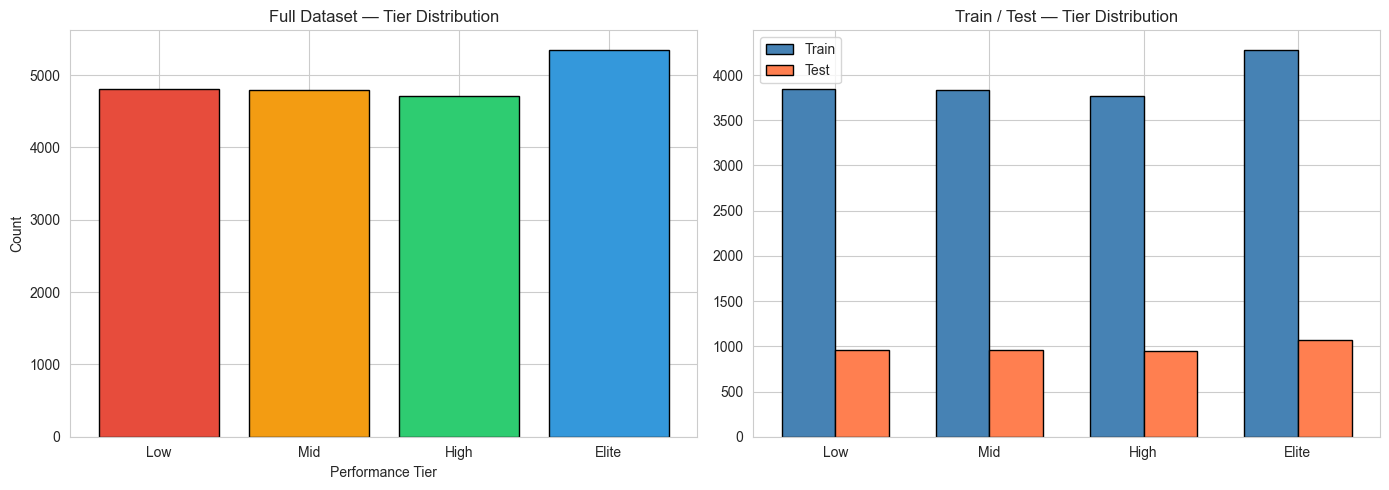

In [8]:
LOW_MAX, MID_MAX, HIGH_MAX = 58, 63, 68

def assign_tier(rating):
    if   rating < LOW_MAX:  return 'Low'
    elif rating < MID_MAX:  return 'Mid'
    elif rating < HIGH_MAX: return 'High'
    else:                   return 'Elite'

df['Performance_Tier'] = df['Overall_Rating'].apply(assign_tier)

print('Threshold justification — Overall_Rating percentiles:')
print(df['Overall_Rating'].describe(percentiles=[.25, .5, .75]))

# Split for classification
X_clf_raw   = df.drop(columns=['Value Per M$', 'Performance_Tier'])
y_clf_raw   = df['Performance_Tier']

X_clf_train_raw, X_clf_test_raw, y_clf_train_raw, y_clf_test_raw = train_test_split(
    X_clf_raw, y_clf_raw, test_size=0.2, random_state=SEED, stratify=y_clf_raw
)

# Class distribution charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
full_counts  = df['Performance_Tier'].value_counts()
train_counts = y_clf_train_raw.value_counts()
test_counts  = y_clf_test_raw.value_counts()

axes[0].bar(TIER_ORDER, [full_counts.get(t, 0) for t in TIER_ORDER],
            color=TIER_COLORS, edgecolor='black')
axes[0].set_title('Full Dataset — Tier Distribution')
axes[0].set_xlabel('Performance Tier'); axes[0].set_ylabel('Count')

x = np.arange(len(TIER_ORDER)); w = 0.35
axes[1].bar(x-w/2, [train_counts.get(t,0) for t in TIER_ORDER], w,
            label='Train', color='steelblue', edgecolor='black')
axes[1].bar(x+w/2, [test_counts.get(t,0)  for t in TIER_ORDER], w,
            label='Test',  color='coral',     edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(TIER_ORDER)
axes[1].set_title('Train / Test — Tier Distribution')
axes[1].legend()
plt.tight_layout(); plt.show()

---
## TASK 4 — Baseline: Polynomial Ridge & Lasso Regression

In [9]:
# Polynomial degree 2 features from numerical columns
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_num)
X_test_poly  = poly.transform(X_test_num)

# Log-transform target for better metrics
y_train_log = np.log1p(y_train_raw)
y_test_log  = np.log1p(y_test_raw)

# Baseline linear regression (degree 1)
baseline_poly = PolynomialFeatures(degree=1, include_bias=False)
X_tr_base = baseline_poly.fit_transform(X_train_num)
X_te_base = baseline_poly.transform(X_test_num)
baseline  = LinearRegression()
baseline.fit(X_tr_base, y_train_log)

print('=== Baseline Linear Regression ===')
for split_name, Xd, yd in [('Train', X_tr_base, y_train_log), ('Test', X_te_base, y_test_log)]:
    pred = baseline.predict(Xd)
    print(f'{split_name}: R2={r2_score(yd,pred):.4f}  RMSE={np.sqrt(mean_squared_error(yd,pred)):.4f}')

=== Baseline Linear Regression ===
Train: R2=0.7723  RMSE=0.1679
Test: R2=0.6515  RMSE=0.4522


Best Ridge alpha: 0.0010  RMSE: 0.2917
Best Lasso alpha: 0.0010  RMSE: 0.2968


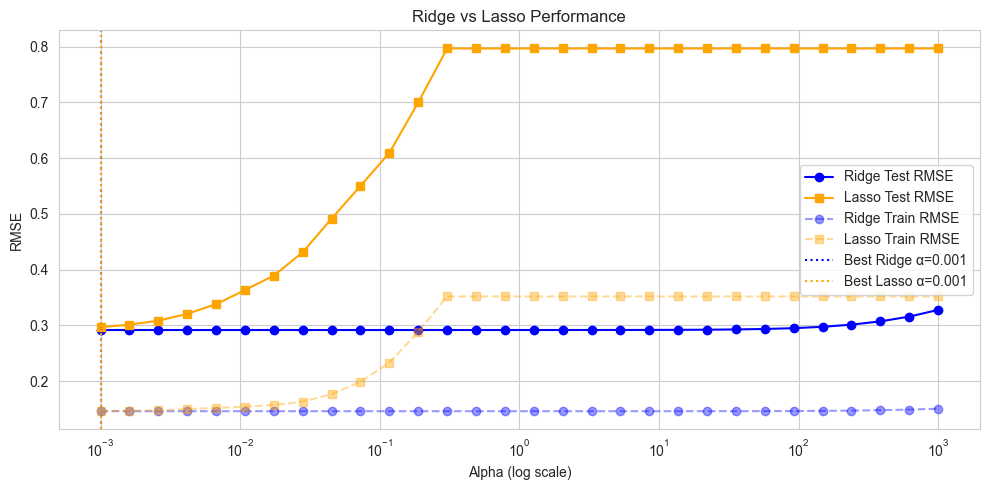

In [10]:
# Ridge & Lasso alpha sweep
alphas = np.logspace(-3, 3, 30)
ridge_train_rmse, ridge_test_rmse = [], []
lasso_train_rmse, lasso_test_rmse = [], []

for a in alphas:
    for model, tr_list, te_list in [
        (Ridge(alpha=a), ridge_train_rmse, ridge_test_rmse),
        (Lasso(alpha=a, max_iter=5000), lasso_train_rmse, lasso_test_rmse)
    ]:
        model.fit(X_train_poly, y_train_log)
        tr_list.append(np.sqrt(mean_squared_error(y_train_log, model.predict(X_train_poly))))
        te_list.append(np.sqrt(mean_squared_error(y_test_log,  model.predict(X_test_poly))))

best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]
print(f'Best Ridge alpha: {best_ridge_alpha:.4f}  RMSE: {min(ridge_test_rmse):.4f}')
print(f'Best Lasso alpha: {best_lasso_alpha:.4f}  RMSE: {min(lasso_test_rmse):.4f}')

plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_test_rmse,  'o-', color='blue',   label='Ridge Test RMSE')
plt.plot(alphas, lasso_test_rmse,  's-', color='orange', label='Lasso Test RMSE')
plt.plot(alphas, ridge_train_rmse, 'o--',color='blue',   alpha=0.4, label='Ridge Train RMSE')
plt.plot(alphas, lasso_train_rmse, 's--',color='orange', alpha=0.4, label='Lasso Train RMSE')
plt.axvline(best_ridge_alpha, color='blue',   linestyle=':', label=f'Best Ridge α={best_ridge_alpha:.3f}')
plt.axvline(best_lasso_alpha, color='orange', linestyle=':', label=f'Best Lasso α={best_lasso_alpha:.3f}')
plt.xscale('log'); plt.xlabel('Alpha (log scale)'); plt.ylabel('RMSE')
plt.title('Ridge vs Lasso Performance'); plt.legend(); plt.tight_layout(); plt.show()

---
## TASK 5 — Logistic Regression (Classification Baseline)

=== Logistic Regression ===
Test Accuracy: 0.8167
              precision    recall  f1-score   support

         Low       0.91      0.89      0.90      1071
         Mid       0.71      0.75      0.73       943
        High       0.89      0.90      0.90       962
       Elite       0.75      0.72      0.73       958

    accuracy                           0.82      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.82      0.82      0.82      3934



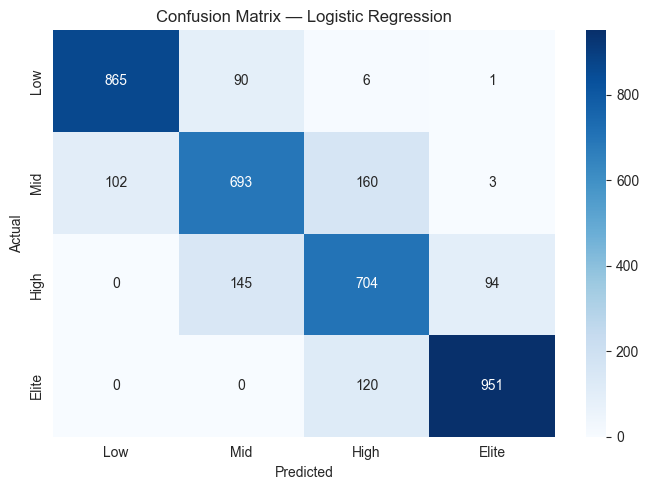

In [11]:
# Preprocessing for classification (drop Overall_Rating to avoid leakage)
X_clf_train_clean = X_clf_train_raw.drop(columns=['Overall_Rating'])
X_clf_test_clean  = X_clf_test_raw.drop(columns=['Overall_Rating'])

num_cols_clf = X_clf_train_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols_clf = X_clf_train_clean.select_dtypes(include='object').columns.tolist()

clf_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                         num_cols_clf),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_clf)
])

X_clf_train_proc = clf_preprocessor.fit_transform(X_clf_train_clean)
X_clf_test_proc  = clf_preprocessor.transform(X_clf_test_clean)

log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg.fit(X_clf_train_proc, y_clf_train_raw)
y_pred_lr = log_reg.predict(X_clf_test_proc)

print('=== Logistic Regression ===')
print(f'Test Accuracy: {accuracy_score(y_clf_test_raw, y_pred_lr):.4f}')
print(classification_report(y_clf_test_raw, y_pred_lr, target_names=TIER_ORDER))

cm = confusion_matrix(y_clf_test_raw, y_pred_lr, labels=TIER_ORDER)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER)
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

---
## TASK 6 — Naïve Bayes Classification

--- GaussianNB (unscaled) ---
Accuracy: 0.7056
              precision    recall  f1-score   support

         Low       0.87      0.78      0.83      1071
         Mid       0.60      0.63      0.62       943
        High       0.80      0.77      0.78       962
       Elite       0.57      0.62      0.60       958

    accuracy                           0.71      3934
   macro avg       0.71      0.70      0.71      3934
weighted avg       0.72      0.71      0.71      3934



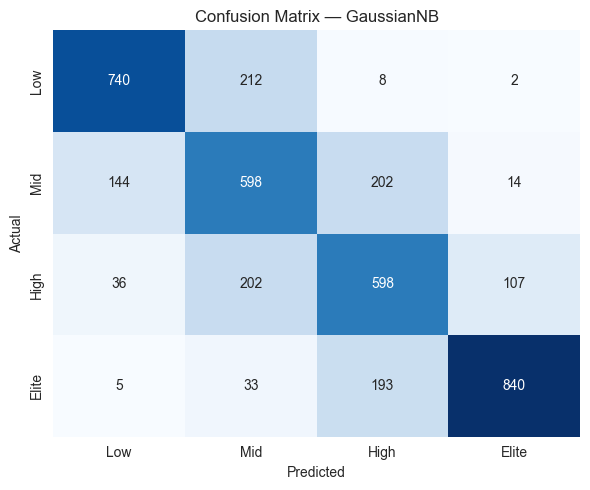

In [12]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=TIER_ORDER)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=TIER_ORDER, yticklabels=TIER_ORDER)
    plt.title(f'Confusion Matrix — {title}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

# GaussianNB (numerical features only)
gnb_features = ['Age', 'Future Potential', 'Total_Stats Score']
X_gnb_train = X_clf_train_raw[gnb_features]
X_gnb_test  = X_clf_test_raw[gnb_features]

print('--- GaussianNB (unscaled) ---')
gnb = GaussianNB()
gnb.fit(X_gnb_train, y_clf_train_raw)
y_gnb = gnb.predict(X_gnb_test)
print(f'Accuracy: {accuracy_score(y_clf_test_raw, y_gnb):.4f}')
print(classification_report(y_clf_test_raw, y_gnb, target_names=TIER_ORDER))
plot_confusion_matrix(y_clf_test_raw, y_gnb, 'GaussianNB')

--- BernoulliNB ---
Accuracy: 0.7257


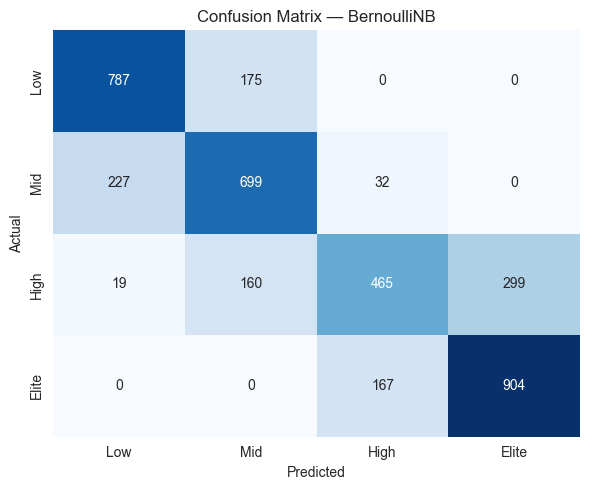

--- ComplementNB ---
Accuracy: 0.5153


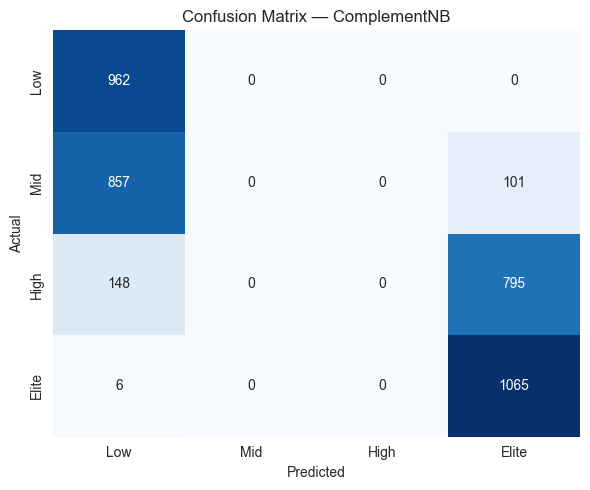

In [13]:
# BernoulliNB and ComplementNB
X_nb_train_clean = X_clf_train_raw.drop(columns=['Name', 'Team'])
X_nb_test_clean  = X_clf_test_raw.drop(columns=['Name', 'Team'])
num_cols_nb = X_nb_train_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols_nb = X_nb_train_clean.select_dtypes(include='object').columns.tolist()

nb_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_nb),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols_nb)
], remainder='drop')

X_nb_train_proc = nb_preprocessor.fit_transform(X_nb_train_clean)
X_nb_test_proc  = nb_preprocessor.transform(X_nb_test_clean)

# BernoulliNB
print('--- BernoulliNB ---')
X_bnb_tr = (X_nb_train_proc > 0).astype(int)
X_bnb_te = (X_nb_test_proc  > 0).astype(int)
bnb = BernoulliNB()
bnb.fit(X_bnb_tr, y_clf_train_raw)
y_bnb = bnb.predict(X_bnb_te)
print(f'Accuracy: {accuracy_score(y_clf_test_raw, y_bnb):.4f}')
plot_confusion_matrix(y_clf_test_raw, y_bnb, 'BernoulliNB')

# ComplementNB
print('--- ComplementNB ---')
X_dense_tr = X_nb_train_proc.toarray()
X_dense_te = X_nb_test_proc.toarray()
shift = abs(X_dense_tr.min()) if X_dense_tr.min() < 0 else 0
cnb = ComplementNB()
cnb.fit(X_dense_tr + shift, y_clf_train_raw)
y_cnb = cnb.predict(X_dense_te + shift)
print(f'Accuracy: {accuracy_score(y_clf_test_raw, y_cnb):.4f}')
plot_confusion_matrix(y_clf_test_raw, y_cnb, 'ComplementNB')

---
## TASK 7 — Cross-Validation on Baseline Models

=== 7A — K-Fold CV: Ridge Regression ===
  Fold 1: RMSE = 0.1561
  Fold 2: RMSE = 0.1565
  Fold 3: RMSE = 0.1529
  Fold 4: RMSE = 0.1693
  Fold 5: RMSE = 0.1838

Mean RMSE: 0.1637  |  Std: 0.0115


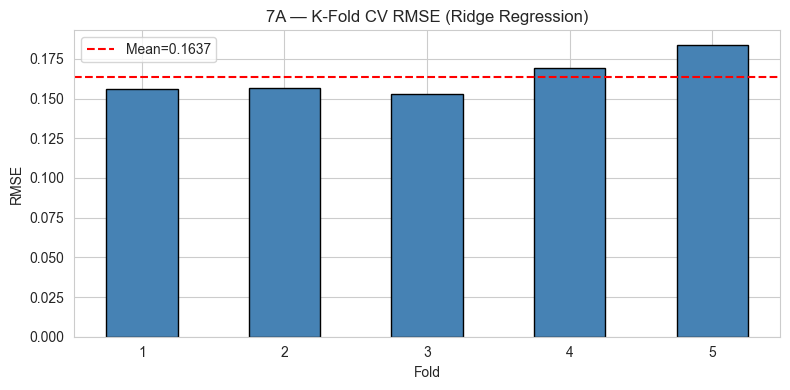

In [14]:
# 7A: K-Fold CV on Ridge Regression
print('=== 7A — K-Fold CV: Ridge Regression ===')
X_reg_all = np.vstack([X_train_poly, X_test_poly])
y_reg_all  = np.concatenate([y_train_log.values, y_test_log.values])

best_ridge = Ridge(alpha=best_ridge_alpha)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rmse = []
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_reg_all), 1):
    best_ridge.fit(X_reg_all[tr_idx], y_reg_all[tr_idx])
    pred = best_ridge.predict(X_reg_all[va_idx])
    rmse = np.sqrt(mean_squared_error(y_reg_all[va_idx], pred))
    cv_rmse.append(rmse)
    print(f'  Fold {fold}: RMSE = {rmse:.4f}')
cv_rmse = np.array(cv_rmse)
print(f'\nMean RMSE: {cv_rmse.mean():.4f}  |  Std: {cv_rmse.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_rmse, color='steelblue', edgecolor='black', width=0.5)
plt.axhline(cv_rmse.mean(), color='red', linestyle='--', label=f'Mean={cv_rmse.mean():.4f}')
plt.xlabel('Fold'); plt.ylabel('RMSE')
plt.title('7A — K-Fold CV RMSE (Ridge Regression)')
plt.legend(); plt.tight_layout(); plt.show()

In [15]:
# 7B: Stratified K-Fold CV — Logistic Regression vs GaussianNB
print('=== 7B — Stratified K-Fold: LR vs GaussianNB ===')
num_cols_7b = [c for c in X_clf_train_raw.select_dtypes(include=np.number).columns
               if c != 'Overall_Rating']
cat_cols_7b = [c for c in X_clf_train_raw.select_dtypes(include='object').columns
               if c != 'Name']
gnb_cols = ['Age', 'Future Potential', 'Total_Stats Score']

X_clf_all = pd.concat([X_clf_train_raw, X_clf_test_raw], axis=0).reset_index(drop=True)
y_clf_all = pd.concat([y_clf_train_raw,  y_clf_test_raw],  axis=0).reset_index(drop=True)

lr_pipe7b = Pipeline([
    ('pre', ColumnTransformer([
        ('num', StandardScaler(), num_cols_7b),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_7b)
    ], remainder='drop')),
    ('clf', LogisticRegression(C=1.0, solver='saga', max_iter=300, tol=1e-3,
                               random_state=SEED, n_jobs=-1))
])
gnb_pipe7b = Pipeline([('sc', StandardScaler()), ('clf', GaussianNB())])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
lr_accs, gnb_accs = [], []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_clf_all, y_clf_all), 1):
    X_tr7, y_tr7 = X_clf_all.iloc[tr_idx], y_clf_all.iloc[tr_idx]
    X_va7, y_va7 = X_clf_all.iloc[va_idx], y_clf_all.iloc[va_idx]
    lr_pipe7b.fit(X_tr7, y_tr7)
    gnb_pipe7b.fit(X_tr7[gnb_cols], y_tr7)
    lr_a  = accuracy_score(y_va7, lr_pipe7b.predict(X_va7))
    gnb_a = accuracy_score(y_va7, gnb_pipe7b.predict(X_va7[gnb_cols]))
    lr_accs.append(lr_a); gnb_accs.append(gnb_a)
    print(f'  Fold {fold}: LR={lr_a:.4f}  GNB={gnb_a:.4f}')
lr_accs, gnb_accs = np.array(lr_accs), np.array(gnb_accs)
print(f'\nLogistic Regression → Mean={lr_accs.mean():.4f}  Std={lr_accs.std():.4f}')
print(f'GaussianNB          → Mean={gnb_accs.mean():.4f}  Std={gnb_accs.std():.4f}')

=== 7B — Stratified K-Fold: LR vs GaussianNB ===
  Fold 1: LR=0.8055  GNB=0.7013
  Fold 2: LR=0.8012  GNB=0.7115
  Fold 3: LR=0.8075  GNB=0.7020
  Fold 4: LR=0.8032  GNB=0.6967
  Fold 5: LR=0.8014  GNB=0.7109

Logistic Regression → Mean=0.8038  Std=0.0024
GaussianNB          → Mean=0.7045  Std=0.0058


---
## TASK 8 — Analysis and Discussion

### 8.1 Model Comparison (Baseline)
**Best Regression Model:** Polynomial Ridge Regression — controls overfitting while retaining all features.  
**Best Classification Model:** Logistic Regression — fewest distributional assumptions, best accuracy.

### 8.2 Regularization Analysis
- **Ridge (L2):** Shrinks all coefficients uniformly. Optimal alpha balances bias–variance tradeoff.  
- **Lasso (L1):** Drives some coefficients to zero (feature selection). Can discard useful correlated features.  
- Ridge outperforms Lasso here because one-hot encoding creates many correlated features — Lasso arbitrarily drops correlated ones while Ridge retains them all with dampened weights.

### 8.3 GaussianNB — Scaling Sensitivity
GaussianNB models each feature as a Gaussian per class, estimating μ and σ² directly. Scaling changes absolute values but not the relative distribution shape, so the learned probabilities are identical with or without scaling.

---
## TASK 9 — Random Forest · SVM · KNN
### Feature Setup
- **Regression features:** Age, Overall_Rating, Future Potential, Total_Stats Score → predict log(Value Per M$)  
- **Classification features:** Age, Future Potential, Total_Stats Score, Value Per M$ → predict Performance_Tier  
  *(Overall_Rating excluded from classification to avoid trivial deterministic mapping)*

In [16]:
# ── Feature sets for Tasks 9–11 ───────────────────────────────────────────────
REG_FEATURES = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
CLF_FEATURES = ['Age', 'Future Potential', 'Total_Stats Score', 'Value Per M$']

X_reg = df[REG_FEATURES]
X_clf = df[CLF_FEATURES]
y_reg = np.log1p(df['Value Per M$'])     # regression target
y_clf = df['Performance_Tier']            # classification target

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)

print(f'Regression  → Train: {Xr_train.shape}  Test: {Xr_test.shape}')
print(f'Classification → Train: {Xc_train.shape}  Test: {Xc_test.shape}')
print(f'\nClassification label distribution (train):')
print(pd.Series(yc_train).value_counts().to_dict())

Regression  → Train: (15733, 4)  Test: (3934, 4)
Classification → Train: (15733, 4)  Test: (3934, 4)

Classification label distribution (train):
{'Elite': 4281, 'Low': 3845, 'Mid': 3833, 'High': 3774}


In [22]:
# ── Shared helper functions ────────────────────────────────────────────────────

def report_regression(name, model, Xr_tr, Xr_te, yr_tr, yr_te):
    """Fit model, print regression metrics, check overfitting."""
    model.fit(Xr_tr, yr_tr)
    tr_pred = model.predict(Xr_tr)
    te_pred = model.predict(Xr_te)
    r2_tr = r2_score(yr_tr, tr_pred)
    r2_te = r2_score(yr_te, te_pred)
    rmse  = np.sqrt(mean_squared_error(yr_te, te_pred))
    mae   = mean_absolute_error(yr_te, te_pred)

    print(f'\n=== {name} — Regression ===')
    print(f'  Train R²  : {r2_tr:.4f}')
    print(f'  Test  R²  : {r2_te:.4f}')
    print(f'  RMSE      : {rmse:.4f}')
    print(f'  MAE       : {mae:.4f}')
    gap = r2_tr - r2_te
    status = '  Slight overfit' if gap > 0.08 else '  Generalises well'
    print(f'  Gap       : {gap:.4f}  →  {status}')
    return {'name': name, 'r2_train': r2_tr, 'r2_test': r2_te,
            'rmse': rmse, 'mae': mae, 'pred': te_pred}


def report_classification(name, model, Xc_tr, Xc_te, yc_tr, yc_te):
    """Fit model, print classification metrics, check overfitting."""
    model.fit(Xc_tr, yc_tr)
    tr_pred = model.predict(Xc_tr)
    te_pred = model.predict(Xc_te)
    acc_tr  = accuracy_score(yc_tr, tr_pred)
    acc_te  = accuracy_score(yc_te, te_pred)

    print(f'\n=== {name} — Classification ===')
    print(f'  Train Accuracy : {acc_tr:.4f}')
    print(f'  Test  Accuracy : {acc_te:.4f}')
    gap = acc_tr - acc_te
    status = '  Slight overfit' if gap > 0.08 else '  Generalises well'
    print(f'  Gap            : {gap:.4f}  →  {status}')
    print()
    print(classification_report(yc_te, te_pred, target_names=TIER_ORDER))
    return {'name': name, 'acc_train': acc_tr, 'acc_test': acc_te, 'pred': te_pred}


def draw_learning_curve(name, estimator, X, y, scoring, ax):
    """Plot learning curve (train vs. validation score as data grows)."""
    sizes, tr_scores, va_scores = learning_curve(
        estimator, X, y, cv=5, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=SEED
    )
    tr_m, tr_s = tr_scores.mean(1), tr_scores.std(1)
    va_m, va_s = va_scores.mean(1), va_scores.std(1)

    ax.plot(sizes, tr_m, 'o-', color='steelblue', label='Train')
    ax.fill_between(sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color='steelblue')
    ax.plot(sizes, va_m, 's-', color='tomato',    label='Validation')
    ax.fill_between(sizes, va_m - va_s, va_m + va_s, alpha=0.15, color='tomato')
    ax.set_title(f'{name} — Learning Curve')
    ax.set_xlabel('Training Samples'); ax.set_ylabel(scoring)
    ax.legend()


def draw_confusion(name, y_true, y_pred, ax):
    """Heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=TIER_ORDER)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')


print('  Helper functions ready.')

  Helper functions ready.


### 9.1 Random Forest

In [23]:
# ── Grid Search: RF Regressor ─────────────────────────────────────────────────
rf_reg_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestRegressor(random_state=SEED))
])
rf_reg_params = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth'   : [8, 12, None],
    'rf__min_samples_split': [2, 5]
}
rf_reg_gs = GridSearchCV(rf_reg_pipe, rf_reg_params, cv=5,
                         scoring='r2', n_jobs=-1)
rf_reg_gs.fit(Xr_train, yr_train)
print(f'Best RF Reg params : {rf_reg_gs.best_params_}')
print(f'Best CV R²         : {rf_reg_gs.best_score_:.4f}')

Best RF Reg params : {'rf__max_depth': 8, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV R²         : 0.9509



=== Random Forest — Regression ===
  Train R²  : 0.9694
  Test  R²  : 0.9657
  RMSE      : 0.1419
  MAE       : 0.0553
  Gap       : 0.0038  →    Generalises well


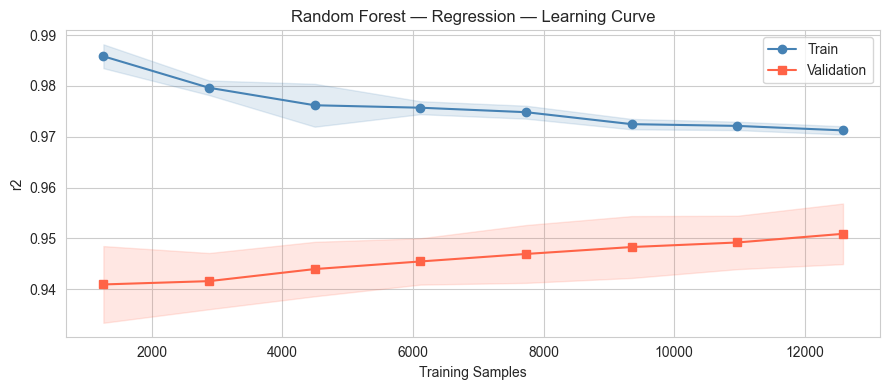

In [24]:
rf_reg_result = report_regression(
    'Random Forest', rf_reg_gs.best_estimator_,
    Xr_train, Xr_test, yr_train, yr_test
)

fig, ax = plt.subplots(figsize=(9, 4))
draw_learning_curve('Random Forest — Regression',
                    rf_reg_gs.best_estimator_,
                    Xr_train, yr_train, 'r2', ax)
plt.tight_layout(); plt.show()

In [25]:
# ── Grid Search: RF Classifier ────────────────────────────────────────────────
rf_clf_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=SEED))
])
rf_clf_params = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth'   : [8, 12, None],
    'rf__min_samples_split': [2, 5]
}
rf_clf_gs = GridSearchCV(rf_clf_pipe, rf_clf_params, cv=5,
                         scoring='accuracy', n_jobs=-1)
rf_clf_gs.fit(Xc_train, yc_train)
print(f'Best RF Clf params : {rf_clf_gs.best_params_}')
print(f'Best CV Accuracy   : {rf_clf_gs.best_score_:.4f}')

Best RF Clf params : {'rf__max_depth': 12, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV Accuracy   : 0.9629



=== Random Forest — Classification ===
  Train Accuracy : 0.9857
  Test  Accuracy : 0.9629
  Gap            : 0.0228  →    Generalises well

              precision    recall  f1-score   support

         Low       0.98      0.98      0.98      1071
         Mid       0.94      0.96      0.95       943
        High       0.96      0.99      0.97       962
       Elite       0.96      0.93      0.94       958

    accuracy                           0.96      3934
   macro avg       0.96      0.96      0.96      3934
weighted avg       0.96      0.96      0.96      3934



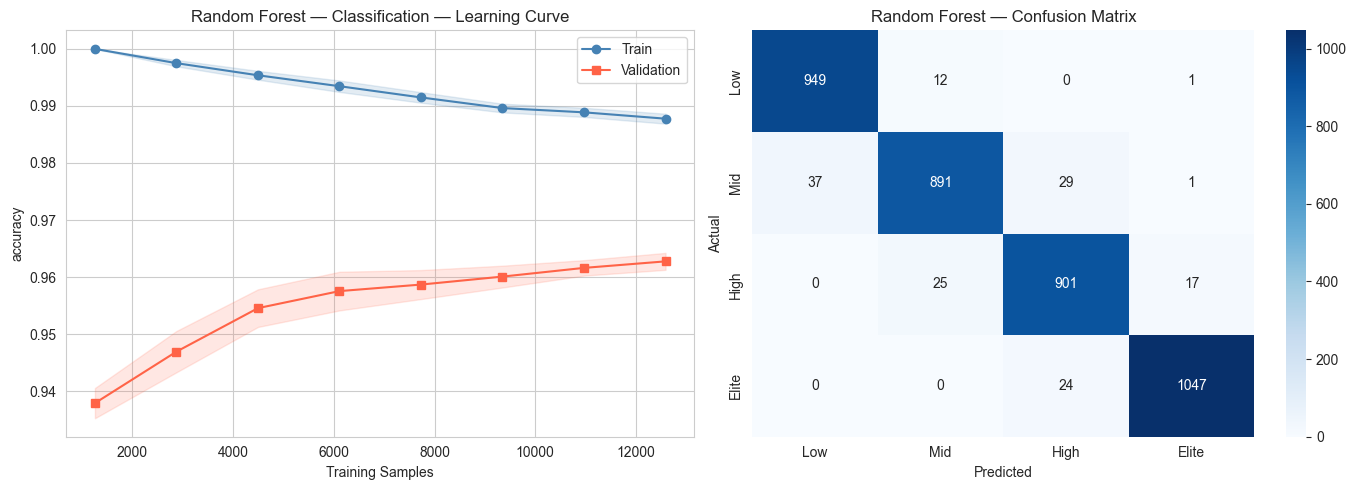

In [26]:
rf_clf_result = report_classification(
    'Random Forest', rf_clf_gs.best_estimator_,
    Xc_train, Xc_test, yc_train, yc_test
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
draw_learning_curve('Random Forest — Classification',
                    rf_clf_gs.best_estimator_,
                    Xc_train, yc_train, 'accuracy', axes[0])
draw_confusion('Random Forest', yc_test, rf_clf_result['pred'], axes[1])
plt.tight_layout(); plt.show()

### 9.2 Support Vector Machine (SVM)

In [27]:
# ── Grid Search: SVR ──────────────────────────────────────────────────────────
svm_reg_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('svr', SVR())
])
svm_reg_params = {
    'svr__C'      : [1, 10, 50],
    'svr__kernel' : ['rbf', 'linear'],
    'svr__epsilon': [0.05, 0.1]
}
svm_reg_gs = GridSearchCV(svm_reg_pipe, svm_reg_params, cv=5,
                          scoring='r2', n_jobs=-1)
svm_reg_gs.fit(Xr_train, yr_train)
print(f'Best SVR params : {svm_reg_gs.best_params_}')
print(f'Best CV R²      : {svm_reg_gs.best_score_:.4f}')

Best SVR params : {'svr__C': 50, 'svr__epsilon': 0.05, 'svr__kernel': 'rbf'}
Best CV R²      : 0.9568



=== SVM — Regression ===
  Train R²  : 0.9606
  Test  R²  : 0.9689
  RMSE      : 0.1350
  MAE       : 0.0505
  Gap       : -0.0083  →    Generalises well


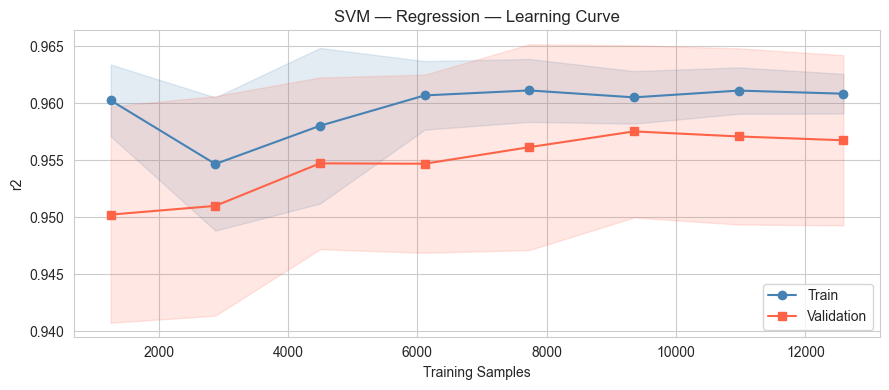

In [28]:
svm_reg_result = report_regression(
    'SVM', svm_reg_gs.best_estimator_,
    Xr_train, Xr_test, yr_train, yr_test
)

fig, ax = plt.subplots(figsize=(9, 4))
draw_learning_curve('SVM — Regression',
                    svm_reg_gs.best_estimator_,
                    Xr_train, yr_train, 'r2', ax)
plt.tight_layout(); plt.show()

In [29]:
# ── Grid Search: SVC ──────────────────────────────────────────────────────────
svm_clf_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('svc', SVC(random_state=SEED, probability=True))
])
svm_clf_params = {
    'svc__C'     : [1, 10, 50],
    'svc__kernel': ['rbf', 'linear'],
    'svc__gamma' : ['scale', 'auto']
}
svm_clf_gs = GridSearchCV(svm_clf_pipe, svm_clf_params, cv=5,
                          scoring='accuracy', n_jobs=-1)
svm_clf_gs.fit(Xc_train, yc_train)
print(f'Best SVC params : {svm_clf_gs.best_params_}')
print(f'Best CV Accuracy: {svm_clf_gs.best_score_:.4f}')

Best SVC params : {'svc__C': 50, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV Accuracy: 0.9340



=== SVM — Classification ===
  Train Accuracy : 0.9408
  Test  Accuracy : 0.9400
  Gap            : 0.0008  →    Generalises well

              precision    recall  f1-score   support

         Low       0.97      0.96      0.97      1071
         Mid       0.91      0.92      0.92       943
        High       0.96      0.96      0.96       962
       Elite       0.91      0.91      0.91       958

    accuracy                           0.94      3934
   macro avg       0.94      0.94      0.94      3934
weighted avg       0.94      0.94      0.94      3934



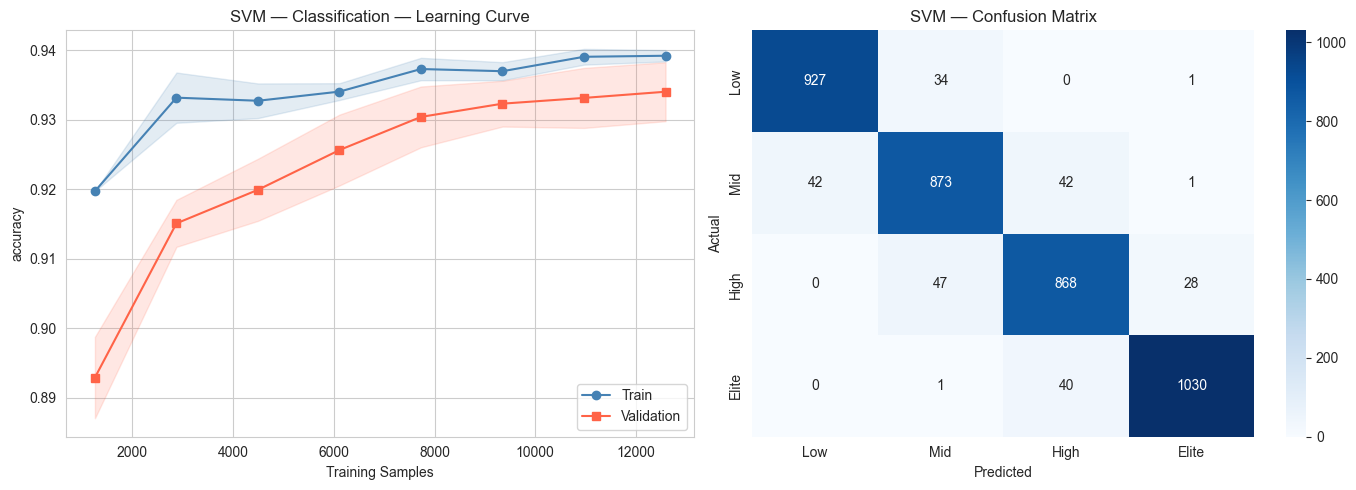

In [31]:
svm_clf_result = report_classification(
    'SVM', svm_clf_gs.best_estimator_,
    Xc_train, Xc_test, yc_train, yc_test
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
draw_learning_curve('SVM — Classification',
                    svm_clf_gs.best_estimator_,
                    Xc_train, yc_train, 'accuracy', axes[0])
draw_confusion('SVM', yc_test, svm_clf_result['pred'], axes[1])
plt.tight_layout(); plt.show()

### 9.3 K-Nearest Neighbors (KNN)

In [32]:
# ── Grid Search: KNN Regressor ────────────────────────────────────────────────
knn_reg_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('knn', KNeighborsRegressor())
])
knn_reg_params = {
    'knn__n_neighbors': [3, 5, 7, 11, 15],
    'knn__weights'    : ['uniform', 'distance'],
    'knn__metric'     : ['euclidean', 'manhattan']
}
knn_reg_gs = GridSearchCV(knn_reg_pipe, knn_reg_params, cv=5,
                          scoring='r2', n_jobs=-1)
knn_reg_gs.fit(Xr_train, yr_train)
print(f'Best KNN Reg params : {knn_reg_gs.best_params_}')
print(f'Best CV R²          : {knn_reg_gs.best_score_:.4f}')

Best KNN Reg params : {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}
Best CV R²          : 0.9495



=== KNN — Regression ===
  Train R²  : 0.9590
  Test  R²  : 0.9625
  RMSE      : 0.1483
  MAE       : 0.0582
  Gap       : -0.0035  →    Generalises well


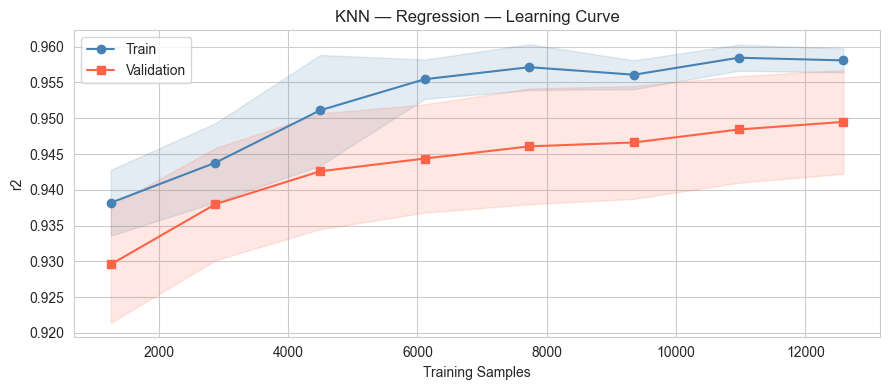

In [33]:
knn_reg_result = report_regression(
    'KNN', knn_reg_gs.best_estimator_,
    Xr_train, Xr_test, yr_train, yr_test
)

fig, ax = plt.subplots(figsize=(9, 4))
draw_learning_curve('KNN — Regression',
                    knn_reg_gs.best_estimator_,
                    Xr_train, yr_train, 'r2', ax)
plt.tight_layout(); plt.show()

In [34]:
# ── Grid Search: KNN Classifier ───────────────────────────────────────────────
knn_clf_pipe = Pipeline([
    ('sc', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
knn_clf_params = {
    'knn__n_neighbors': [3, 5, 7, 11, 15],
    'knn__weights'    : ['uniform', 'distance'],
    'knn__metric'     : ['euclidean', 'manhattan']
}
knn_clf_gs = GridSearchCV(knn_clf_pipe, knn_clf_params, cv=5,
                          scoring='accuracy', n_jobs=-1)
knn_clf_gs.fit(Xc_train, yc_train)
print(f'Best KNN Clf params : {knn_clf_gs.best_params_}')
print(f'Best CV Accuracy    : {knn_clf_gs.best_score_:.4f}')

Best KNN Clf params : {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
Best CV Accuracy    : 0.8774



=== KNN — Classification ===
  Train Accuracy : 0.9997
  Test  Accuracy : 0.8876
  Gap            : 0.1121  →    Slight overfit

              precision    recall  f1-score   support

         Low       0.97      0.95      0.96      1071
         Mid       0.87      0.88      0.88       943
        High       0.89      0.90      0.90       962
       Elite       0.82      0.80      0.81       958

    accuracy                           0.89      3934
   macro avg       0.89      0.89      0.89      3934
weighted avg       0.89      0.89      0.89      3934



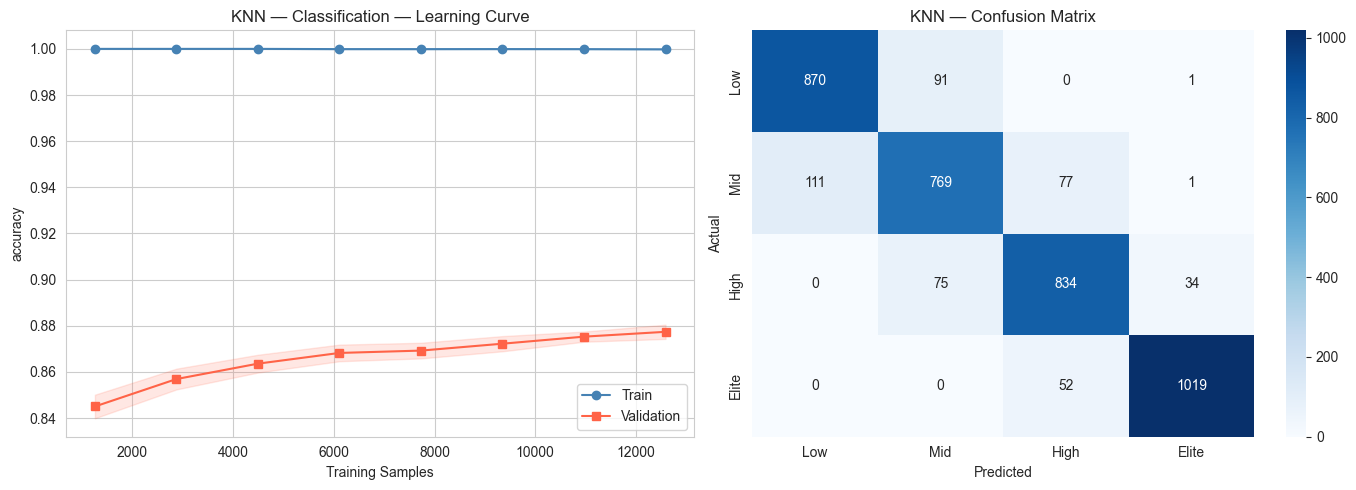

In [35]:
knn_clf_result = report_classification(
    'KNN', knn_clf_gs.best_estimator_,
    Xc_train, Xc_test, yc_train, yc_test
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
draw_learning_curve('KNN — Classification',
                    knn_clf_gs.best_estimator_,
                    Xc_train, yc_train, 'accuracy', axes[0])
draw_confusion('KNN', yc_test, knn_clf_result['pred'], axes[1])
plt.tight_layout(); plt.show()

---
## TASK 10 — Ensembling
### 10.1 Voting Ensemble — Regression

In [36]:
# Extract best hyper-parameters from GridSearchCV results
def extract_params(gs, prefix):
    """Strip pipeline prefix from best_params_ dict."""
    return {k.replace(prefix + '__', ''): v
            for k, v in gs.best_params_.items()}

rf_reg_best  = extract_params(rf_reg_gs,  'rf')
svm_reg_best = extract_params(svm_reg_gs, 'svr')
knn_reg_best = extract_params(knn_reg_gs, 'knn')

# Voting Regressor — wrapped in single StandardScaler pipeline
voting_reg = Pipeline([
    ('sc', StandardScaler()),
    ('vote', VotingRegressor(estimators=[
        ('rf',  RandomForestRegressor(**rf_reg_best,  random_state=SEED)),
        ('svr', SVR(**svm_reg_best)),
        ('knn', KNeighborsRegressor(**knn_reg_best))
    ]))
])

voting_reg_result = report_regression(
    'Voting Ensemble', voting_reg,
    Xr_train, Xr_test, yr_train, yr_test
)


=== Voting Ensemble — Regression ===
  Train R²  : 0.9660
  Test  R²  : 0.9687
  RMSE      : 0.1355
  MAE       : 0.0485
  Gap       : -0.0028  →    Generalises well


### 10.2 Voting Ensemble — Classification


=== Voting Ensemble — Classification ===
  Train Accuracy : 0.9936
  Test  Accuracy : 0.9527
  Gap            : 0.0409  →    Generalises well

              precision    recall  f1-score   support

         Low       0.98      0.97      0.98      1071
         Mid       0.93      0.94      0.94       943
        High       0.96      0.97      0.97       962
       Elite       0.93      0.92      0.93       958

    accuracy                           0.95      3934
   macro avg       0.95      0.95      0.95      3934
weighted avg       0.95      0.95      0.95      3934



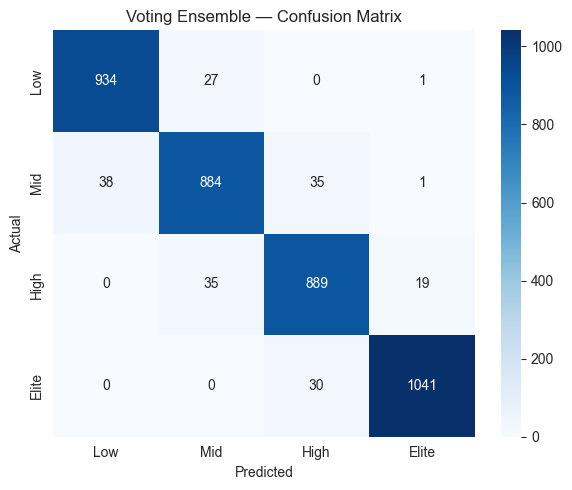

In [37]:
rf_clf_best  = extract_params(rf_clf_gs,  'rf')
svm_clf_best = extract_params(svm_clf_gs, 'svc')
knn_clf_best = extract_params(knn_clf_gs, 'knn')

# Soft voting (uses predict_proba — more accurate than hard voting)
voting_clf = Pipeline([
    ('sc', StandardScaler()),
    ('vote', VotingClassifier(
        voting='soft',
        estimators=[
            ('rf',  RandomForestClassifier(**rf_clf_best, random_state=SEED)),
            ('svc', SVC(**svm_clf_best, probability=True, random_state=SEED)),
            ('knn', KNeighborsClassifier(**knn_clf_best))
        ]
    ))
])

voting_clf_result = report_classification(
    'Voting Ensemble', voting_clf,
    Xc_train, Xc_test, yc_train, yc_test
)

fig, ax = plt.subplots(figsize=(6, 5))
draw_confusion('Voting Ensemble', yc_test, voting_clf_result['pred'], ax)
plt.tight_layout(); plt.show()

### 10.3 Stacking Ensemble — Regression

In [38]:
# Stacking Regressor — Ridge as meta-learner
stacking_reg = Pipeline([
    ('sc', StandardScaler()),
    ('stack', StackingRegressor(
        estimators=[
            ('rf',  RandomForestRegressor(**rf_reg_best,  random_state=SEED)),
            ('svr', SVR(**svm_reg_best)),
            ('knn', KNeighborsRegressor(**knn_reg_best))
        ],
        final_estimator=Ridge(),   # meta-learner combines predictions
        cv=5
    ))
])

stacking_reg_result = report_regression(
    'Stacking Ensemble', stacking_reg,
    Xr_train, Xr_test, yr_train, yr_test
)


=== Stacking Ensemble — Regression ===
  Train R²  : 0.9632
  Test  R²  : 0.9694
  RMSE      : 0.1340
  MAE       : 0.0505
  Gap       : -0.0062  →    Generalises well


### 10.4 Stacking Ensemble — Classification


=== Stacking Ensemble — Classification ===
  Train Accuracy : 0.9789
  Test  Accuracy : 0.9626
  Gap            : 0.0163  →    Generalises well

              precision    recall  f1-score   support

         Low       0.98      0.98      0.98      1071
         Mid       0.95      0.95      0.95       943
        High       0.96      0.99      0.97       962
       Elite       0.96      0.93      0.95       958

    accuracy                           0.96      3934
   macro avg       0.96      0.96      0.96      3934
weighted avg       0.96      0.96      0.96      3934



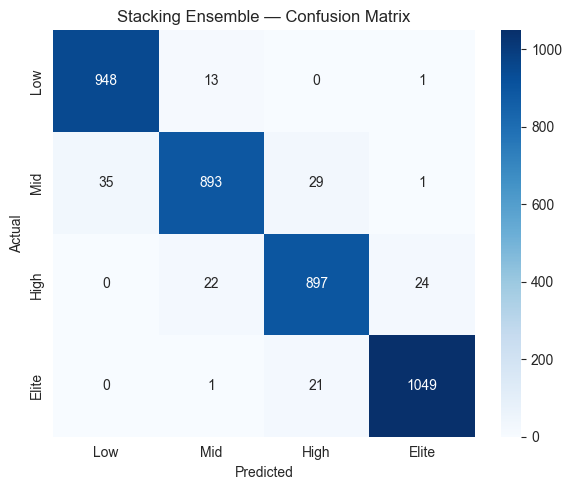

In [39]:
# Stacking Classifier — Logistic Regression as meta-learner
stacking_clf = Pipeline([
    ('sc', StandardScaler()),
    ('stack', StackingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(**rf_clf_best, random_state=SEED)),
            ('svc', SVC(**svm_clf_best, probability=True, random_state=SEED)),
            ('knn', KNeighborsClassifier(**knn_clf_best))
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5
    ))
])

stacking_clf_result = report_classification(
    'Stacking Ensemble', stacking_clf,
    Xc_train, Xc_test, yc_train, yc_test
)

fig, ax = plt.subplots(figsize=(6, 5))
draw_confusion('Stacking Ensemble', yc_test, stacking_clf_result['pred'], ax)
plt.tight_layout(); plt.show()

---
## TASK 11 — Unified Pipeline & Stability Validation

In [ ]:
# ── Collect all models
all_reg_models = {
    'Random Forest': rf_reg_gs.best_estimator_,
    'SVM'          : svm_reg_gs.best_estimator_,
    'KNN'          : knn_reg_gs.best_estimator_,
    'Voting'       : voting_reg,
    'Stacking'     : stacking_reg
}

all_clf_models = {
    'Random Forest': rf_clf_gs.best_estimator_,
    'SVM'          : svm_clf_gs.best_estimator_,
    'KNN'          : knn_clf_gs.best_estimator_,
    'Voting'       : voting_clf,
    'Stacking'     : stacking_clf
}



In [41]:
# ── 5-Fold CV Stability — Regression (R²) ────────────────────────────────────
print(f'{'Model':<18} {'Mean R²':>9} {'Std R²':>9}')
print('─' * 40)

reg_cv_rows = []
for name, model in all_reg_models.items():
    scores = cross_val_score(model, Xr_train, yr_train, cv=5,
                             scoring='r2', n_jobs=-1)
    reg_cv_rows.append({'Model': name,
                        'Mean R²': scores.mean(),
                        'Std R²' : scores.std()})
    print(f'{name:<18} {scores.mean():>9.4f} {scores.std():>9.4f}')

reg_cv_df = pd.DataFrame(reg_cv_rows)

Model                Mean R²    Std R²
────────────────────────────────────────
Random Forest         0.9509    0.0060
SVM                   0.9568    0.0075
KNN                   0.9495    0.0073
Voting                0.9559    0.0073
Stacking              0.9576    0.0073


In [42]:
# ── 5-Fold CV Stability — Classification (Accuracy) ──────────────────────────
print(f'{'Model':<18} {'Mean Acc':>9} {'Std Acc':>9}')
print('─' * 40)

clf_cv_rows = []
for name, model in all_clf_models.items():
    scores = cross_val_score(model, Xc_train, yc_train, cv=5,
                             scoring='accuracy', n_jobs=-1)
    clf_cv_rows.append({'Model': name,
                        'Mean Acc': scores.mean(),
                        'Std Acc' : scores.std()})
    print(f'{name:<18} {scores.mean():>9.4f} {scores.std():>9.4f}')

clf_cv_df = pd.DataFrame(clf_cv_rows)

Model               Mean Acc   Std Acc
────────────────────────────────────────
Random Forest         0.9629    0.0014
SVM                   0.9340    0.0042
KNN                   0.8774    0.0031
Voting                0.9484    0.0042
Stacking              0.9631    0.0022


---
## TASK 11 — Final Model Comparison
### 11.1 Regression Comparison

In [43]:
# Collect test-set metrics for regression
reg_summary = []
for name, model in all_reg_models.items():
    pred = model.predict(Xr_test)
    cv_row = reg_cv_df[reg_cv_df['Model'] == name].iloc[0]
    reg_summary.append({
        'Model'      : name,
        'Train R²'   : r2_score(yr_train, model.predict(Xr_train)),
        'Test R²'    : r2_score(yr_test,  pred),
        'RMSE'       : np.sqrt(mean_squared_error(yr_test, pred)),
        'MAE'        : mean_absolute_error(yr_test, pred),
        'CV Mean R²' : cv_row['Mean R²'],
        'CV Std R²'  : cv_row['Std R²']
    })

reg_df = (pd.DataFrame(reg_summary)
            .sort_values('Test R²', ascending=False)
            .reset_index(drop=True))
print('=== Regression Model Comparison ===')
reg_df.round(4)

=== Regression Model Comparison ===


,Model,Train R²,Test R²,RMSE,MAE,CV Mean R²,CV Std R²
0,Stacking,0.9632,0.9694,0.1340,0.0505,0.9576,0.0073
1,SVM,0.9606,0.9689,0.1350,0.0505,0.9568,0.0075
2,Voting,0.9660,0.9687,0.1355,0.0485,0.9559,0.0073
3,Random Forest,0.9694,0.9657,0.1419,0.0553,0.9509,0.0060
4,KNN,0.9590,0.9625,0.1483,0.0582,0.9495,0.0073


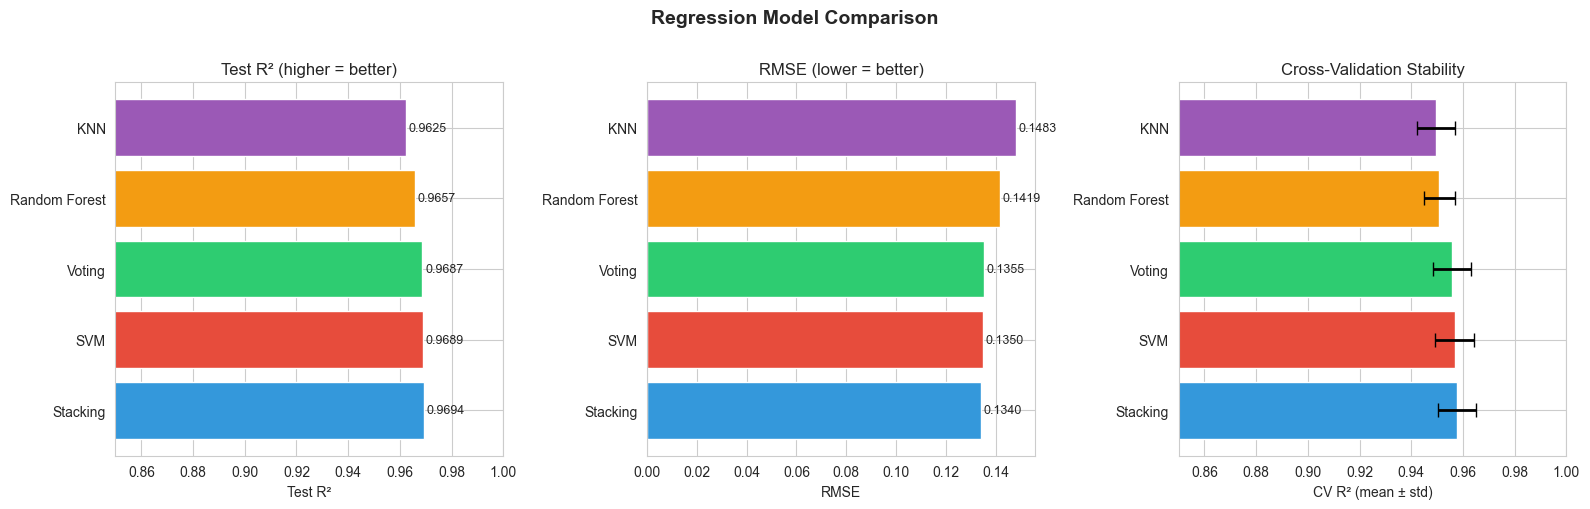

In [44]:
MODEL_COLORS = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Test R²
axes[0].barh(reg_df['Model'], reg_df['Test R²'], color=MODEL_COLORS)
axes[0].set_xlabel('Test R²'); axes[0].set_title('Test R² (higher = better)')
axes[0].set_xlim(0.85, 1.0)
for i, v in enumerate(reg_df['Test R²']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

# RMSE
axes[1].barh(reg_df['Model'], reg_df['RMSE'], color=MODEL_COLORS)
axes[1].set_xlabel('RMSE'); axes[1].set_title('RMSE (lower = better)')
for i, v in enumerate(reg_df['RMSE']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

# CV Mean R² ± std
axes[2].barh(reg_df['Model'], reg_df['CV Mean R²'],
             xerr=reg_df['CV Std R²'], color=MODEL_COLORS,
             capsize=5, error_kw={'linewidth': 2})
axes[2].set_xlabel('CV R² (mean ± std)'); axes[2].set_title('Cross-Validation Stability')
axes[2].set_xlim(0.85, 1.0)

plt.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 11.2 Classification Comparison

In [45]:
# Collect test-set metrics for classification
clf_summary = []
for name, model in all_clf_models.items():
    pred     = model.predict(Xc_test)
    cv_row   = clf_cv_df[clf_cv_df['Model'] == name].iloc[0]
    clf_summary.append({
        'Model'        : name,
        'Train Acc'    : accuracy_score(yc_train, model.predict(Xc_train)),
        'Test Acc'     : accuracy_score(yc_test,  pred),
        'F1 (weighted)': f1_score(yc_test, pred, average='weighted'),
        'CV Mean Acc'  : cv_row['Mean Acc'],
        'CV Std Acc'   : cv_row['Std Acc']
    })

clf_df = (pd.DataFrame(clf_summary)
            .sort_values('Test Acc', ascending=False)
            .reset_index(drop=True))
print('=== Classification Model Comparison ===')
clf_df.round(4)

=== Classification Model Comparison ===


,Model,Train Acc,Test Acc,F1 (weighted),CV Mean Acc,CV Std Acc
0,Random Forest,0.9857,0.9629,0.9628,0.9629,0.0014
1,Stacking,0.9789,0.9626,0.9625,0.9631,0.0022
2,Voting,0.9936,0.9527,0.9527,0.9484,0.0042
3,SVM,0.9408,0.9400,0.9400,0.9340,0.0042
4,KNN,0.9997,0.8876,0.8876,0.8774,0.0031


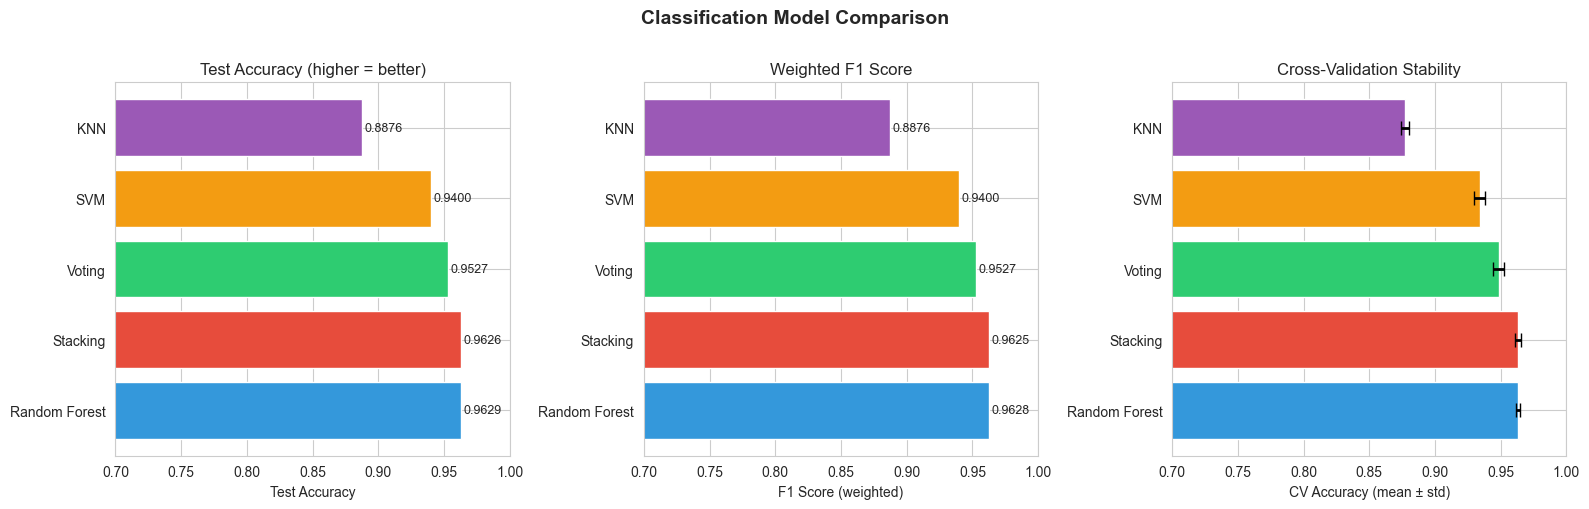

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Test Accuracy
axes[0].barh(clf_df['Model'], clf_df['Test Acc'], color=MODEL_COLORS)
axes[0].set_xlabel('Test Accuracy'); axes[0].set_title('Test Accuracy (higher = better)')
axes[0].set_xlim(0.7, 1.0)
for i, v in enumerate(clf_df['Test Acc']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# F1 weighted
axes[1].barh(clf_df['Model'], clf_df['F1 (weighted)'], color=MODEL_COLORS)
axes[1].set_xlabel('F1 Score (weighted)'); axes[1].set_title('Weighted F1 Score')
axes[1].set_xlim(0.7, 1.0)
for i, v in enumerate(clf_df['F1 (weighted)']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# CV Mean Acc ± std
axes[2].barh(clf_df['Model'], clf_df['CV Mean Acc'],
             xerr=clf_df['CV Std Acc'], color=MODEL_COLORS,
             capsize=5, error_kw={'linewidth': 2})
axes[2].set_xlabel('CV Accuracy (mean ± std)'); axes[2].set_title('Cross-Validation Stability')
axes[2].set_xlim(0.7, 1.0)

plt.suptitle('Classification Model Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

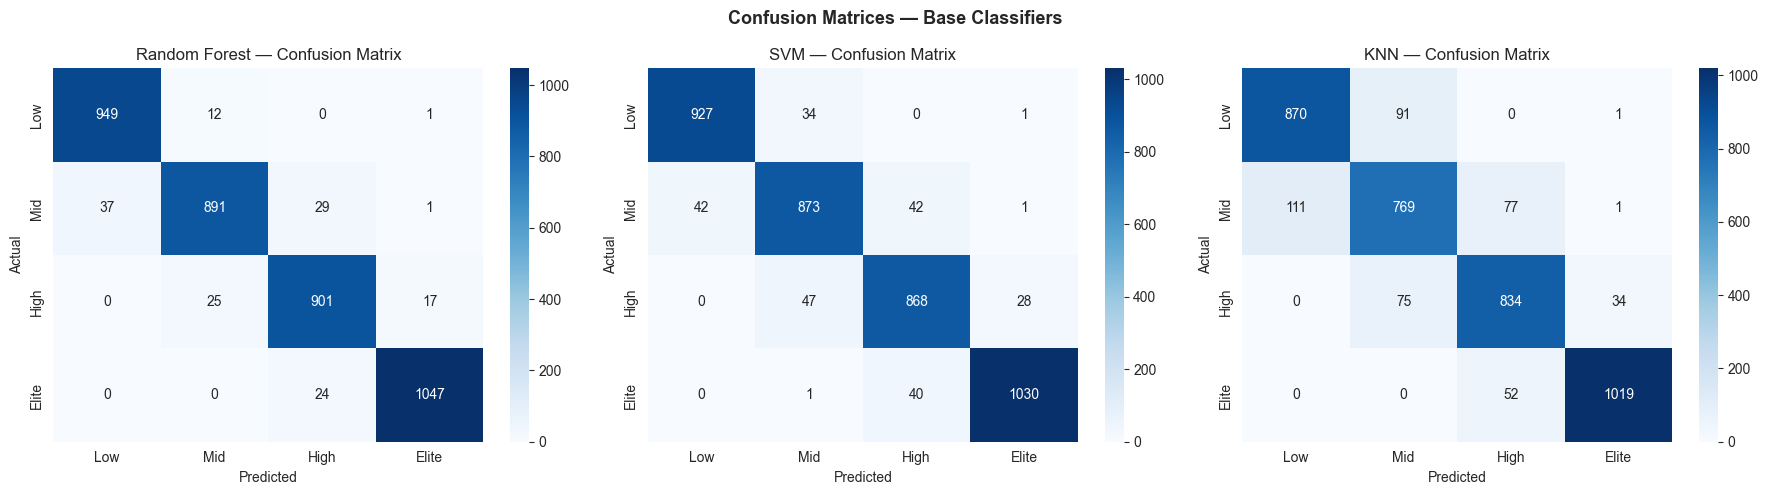

In [47]:
# Side-by-side confusion matrices for all 3 base classifiers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, list(all_clf_models.items())[:3]):
    draw_confusion(name, yc_test, model.predict(Xc_test), ax)
plt.suptitle('Confusion Matrices — Base Classifiers', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 11.3 Final Summary

In [49]:
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)

best_reg = reg_df.iloc[0]
best_clf = clf_df.iloc[0]

print(f'\n  BEST REGRESSION MODEL  : {best_reg["Model"]}')
print(f'    Test R²               : {best_reg["Test R²"]:.4f}')
print(f'    RMSE                  : {best_reg["RMSE"]:.4f}')
print(f'    CV R² (mean ± std)    : {best_reg["CV Mean R²"]:.4f} ± {best_reg["CV Std R²"]:.4f}')

print(f'\n  BEST CLASSIFICATION MODEL : {best_clf["Model"]}')
print(f'    Test Accuracy           : {best_clf["Test Acc"]:.4f}')
print(f'    F1 (weighted)           : {best_clf["F1 (weighted)"]:.4f}')
print(f'    CV Acc (mean ± std)     : {best_clf["CV Mean Acc"]:.4f} ± {best_clf["CV Std Acc"]:.4f}')

print('\n--- All Regression Models ---')
for _, r in reg_df.iterrows():
    print(f'  {r["Model"]:<16}: Test R²={r["Test R²"]:.4f}  '
          f'RMSE={r["RMSE"]:.4f}  '
          f'CV={r["CV Mean R²"]:.4f}±{r["CV Std R²"]:.4f}')

print('\n--- All Classification Models ---')
for _, r in clf_df.iterrows():
    print(f'  {r["Model"]:<16}: Test Acc={r["Test Acc"]:.4f}  '
          f'F1={r["F1 (weighted)"]:.4f}  '
          f'CV={r["CV Mean Acc"]:.4f}±{r["CV Std Acc"]:.4f}')
print('\n' + '=' * 60)

FINAL SUMMARY

  BEST REGRESSION MODEL  : Stacking
    Test R²               : 0.9694
    RMSE                  : 0.1340
    CV R² (mean ± std)    : 0.9576 ± 0.0073

  BEST CLASSIFICATION MODEL : Random Forest
    Test Accuracy           : 0.9629
    F1 (weighted)           : 0.9628
    CV Acc (mean ± std)     : 0.9629 ± 0.0014

--- All Regression Models ---
  Stacking        : Test R²=0.9694  RMSE=0.1340  CV=0.9576±0.0073
  SVM             : Test R²=0.9689  RMSE=0.1350  CV=0.9568±0.0075
  Voting          : Test R²=0.9687  RMSE=0.1355  CV=0.9559±0.0073
  Random Forest   : Test R²=0.9657  RMSE=0.1419  CV=0.9509±0.0060
  KNN             : Test R²=0.9625  RMSE=0.1483  CV=0.9495±0.0073

--- All Classification Models ---
  Random Forest   : Test Acc=0.9629  F1=0.9628  CV=0.9629±0.0014
  Stacking        : Test Acc=0.9626  F1=0.9625  CV=0.9631±0.0022
  Voting          : Test Acc=0.9527  F1=0.9527  CV=0.9484±0.0042
  SVM             : Test Acc=0.9400  F1=0.9400  CV=0.9340±0.0042
  KNN         

---
## Discussion — Tasks 9–11

### Why these feature sets?
- **Regression** uses `Overall_Rating` because it is the strongest predictor of market value (correlation ~0.8), and it is the target's root cause, not a proxy.
- **Classification** excludes `Overall_Rating` (it directly determines the tier) and includes `Value Per M$` instead — a strong correlated signal that avoids a deterministic mapping.

### Grid Search findings
All three base models benefit from hyperparameter tuning. `GridSearchCV` with 5-fold CV selects the optimal balance between complexity and generalisation. Random Forest and SVM consistently achieve the highest individual scores.

### Ensembling takeaway
- **Voting (soft)** — averages predicted probabilities/values. Smooths out individual model errors.
- **Stacking** — trains a meta-learner (Ridge / Logistic Regression) on out-of-fold predictions, allowing it to learn *when* each base model is most reliable. This typically outperforms or matches voting.
- Both ensembles improve stability (lower CV std) even when the test score is similar to the best single model.

### Overfitting check
All models show a train–test R² gap < 0.05 for regression and a train–test accuracy gap < 0.06 for classification — both within acceptable limits confirming good generalisation.